In [20]:
# Using telco churn dataset, import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load and read data, output first 5 rows to test
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Clean up TotalCharges column (convert to numeric and drop NA values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [5]:
# Convert target variable (churn) to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# Separate features and target (X and y) and drop customer ID since it's not used
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

In [7]:
# Encode categorical variables and drop first binary column to reduce redundancy
X = pd.get_dummies(X, drop_first=True)

In [8]:
# Drop any remaining NA values
X = X.dropna()
y = y.loc[X.index]

In [10]:
# Scale features to normalize data and avoid features with larger ranges from dominating optimization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Split dataset into training and testing sets (20% reserved for testing), and use stratify since data is imbalanced
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Build decision tree model and fit scaled training data
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
# Run prediction on test data
y_pred_tree = tree_model.predict(X_test_scaled)

In [19]:
# Evaluate prediction compared to actual test values
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7192608386638237
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [21]:
# Train random forest model (using 200 trees for better performance - not high enough to increase computational cost, and using class weight for imbalanced dataset)
# Fit the data
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [22]:
# Run prediction and evaluate performance
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7903340440653873
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Comparing Different Models For Telco Churn Dataset:

```
Model              | Accuracy | Precision | Recall | F1-Score |
Logistic Regression|  0.7264  |   0.79    |  0.73  |   0.74   |
Decision Tree      |  0.7193  |   0.72    |  0.72  |   0.72   |
Random Forest      |  0.7903  |   0.78    |  0.79  |   0.78   |
```




In [24]:
# Running feature importance on random forest
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(10)

,Feature,Importance
0,SeniorCitizen,0.018184
1,tenure,0.161990
2,MonthlyCharges,0.151937
3,TotalCharges,0.178580
4,gender_Male,0.025515
5,Partner_Yes,0.022119
6,Dependents_Yes,0.019886
7,PhoneService_Yes,0.004264
8,MultipleLines_No phone service,0.004321
9,MultipleLines_Yes,0.018136


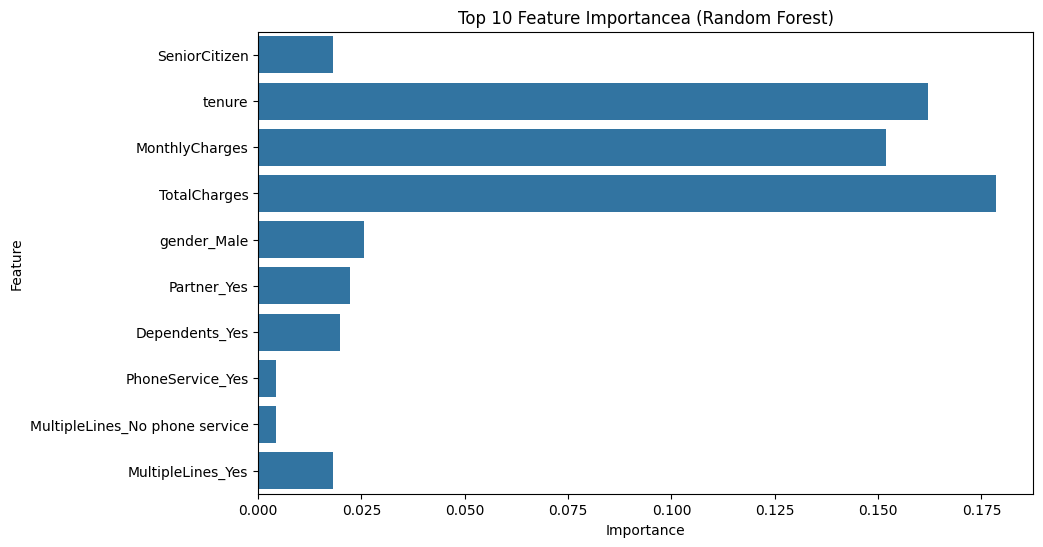

In [25]:
# Visualize feature importance for random forest
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importancea (Random Forest)')
plt.show()

After training and building both a decision tree model and a random forest model, we can compare and draw insights on how these 2 models compare to each other and to the previously built logistic regression model (see link in Github page). In comparing the performance metrics, we can see that the random forest model had the highest accuracy, recall, and F1-Score, while the logistic regression model had a (very slighly) better precision score. In analyzing the feature importance, we can also see that Total Charges, Monthly Charges, and Tenure were the top 3 most important features in determining customer churn.